In [1]:
import os
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

os.chdir("/Users/j.p.barona/Code/Projects/quantihack/")

FEATURE_COLUMNS = [
    "demand", "frequency", "wind", "solar", "hydro", "biomass",
    "ccgt", "coal", "ocgt", "oil", "french_ict", "dutch_ict", "irish_ict",
    "ew_ict", "nemo", "north_south", "scotland_england",
    "pumped", "nuclear",
]
INPUT_WINDOW = 60
FORECAST_HORIZON = 60
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
HIDDEN_WIDTH = 64
DROPOUT = 0.1
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 100

np.random.seed(42)
torch.manual_seed(42)

In [2]:
cleangriddata = pd.read_parquet(
    "data/CleanGridData/data_1h.parquet",
    columns=FEATURE_COLUMNS,
)

cleangriddata["residual_demand"] = (
    cleangriddata["demand"]
    - cleangriddata[["wind", "solar", "hydro", "biomass"]].sum(axis=1)
)
FEATURE_COLUMNS = FEATURE_COLUMNS + ["residual_demand"]
cleangriddata = cleangriddata[FEATURE_COLUMNS]

In [3]:
print("Data shape:", cleangriddata.shape)
print("Columns:", cleangriddata.columns.tolist())
display(cleangriddata.head())
print("Null values per column:")
print(cleangriddata.isnull().sum())

Data shape: (128919, 20)
Columns: ['demand', 'frequency', 'wind', 'solar', 'hydro', 'biomass', 'ccgt', 'coal', 'ocgt', 'oil', 'french_ict', 'dutch_ict', 'irish_ict', 'ew_ict', 'nemo', 'north_south', 'scotland_england', 'pumped', 'nuclear', 'residual_demand']


,demand,frequency,wind,solar,hydro,biomass,ccgt,coal,ocgt,oil,french_ict,dutch_ict,irish_ict,ew_ict,nemo,north_south,scotland_england,pumped,nuclear,residual_demand
0,38859.500000,50.111500,1278.500000,0.0,634.500000,0.0,18198.500000,9305.000000,0.0,0.0,912.000000,0.0,-414.000000,0.0,0.0,0.0,0.0,320.500000,8223.000000,36946.500000
1,38657.083333,50.053000,1480.666667,0.0,635.750000,0.0,17993.333333,9064.750000,0.0,0.0,941.000000,0.0,-414.000000,0.0,0.0,0.0,0.0,290.166667,8207.500000,36540.666667
2,37497.583333,50.020167,1750.583333,0.0,599.333333,0.0,17698.833333,8080.750000,0.0,0.0,920.333333,0.0,-414.000000,0.0,0.0,0.0,0.0,305.500000,8223.166667,35147.666667
3,36146.333333,49.970667,1798.416667,0.0,578.666667,0.0,16381.750000,7765.166667,0.0,0.0,846.000000,0.0,-414.000000,0.0,0.0,0.0,0.0,472.583333,8259.750000,33769.250000
4,34741.166667,50.056082,1913.166667,0.0,540.250000,0.0,15557.833333,7244.500000,0.0,0.0,883.666667,0.0,-414.833333,0.0,0.0,0.0,0.0,308.250000,8315.750000,32287.750000


Null values per column:
demand              0
frequency           0
wind                0
solar               0
hydro               0
biomass             0
ccgt                0
coal                0
ocgt                0
oil                 0
french_ict          0
dutch_ict           0
irish_ict           0
ew_ict              0
nemo                0
north_south         0
scotland_england    0
pumped              0
nuclear             0
residual_demand     0
dtype: int64


## Preprocessing

In [4]:
num_rows = len(cleangriddata)
train_end = int(num_rows * TRAIN_RATIO)
valid_end = train_end + int(num_rows * VALID_RATIO)

train_df = cleangriddata.iloc[:train_end].copy()
valid_df = cleangriddata.iloc[train_end:valid_end].copy()
test_df = cleangriddata.iloc[valid_end:].copy()

print(f"Train rows: {len(train_df)}")
print(f"Valid rows: {len(valid_df)}")
print(f"Test rows: {len(test_df)}")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df.values)
valid_scaled = scaler.transform(valid_df.values)
test_scaled = scaler.transform(test_df.values)

minimum_required = INPUT_WINDOW + FORECAST_HORIZON
assert len(train_scaled) >= minimum_required, "Train split is too short for windowing"
assert len(valid_scaled) >= minimum_required, "Validation split is too short for windowing"
assert len(test_scaled) >= minimum_required, "Test split is too short for windowing"

print("Scaled split shapes:", train_scaled.shape, valid_scaled.shape, test_scaled.shape)

Train rows: 90243
Valid rows: 19337
Test rows: 19339
Scaled split shapes: (90243, 20) (19337, 20) (19339, 20)


## Windowing

In [5]:
TARGET_COLUMN = "residual_demand"
TARGET_INDEX = FEATURE_COLUMNS.index(TARGET_COLUMN)
BASE_FEATURE_COUNT = len(FEATURE_COLUMNS)
DELTA_FEATURE_OFFSET = BASE_FEATURE_COUNT
INPUT_FEATURE_COUNT = BASE_FEATURE_COUNT * 2
TARGET_DELTA_INDEX = DELTA_FEATURE_OFFSET + TARGET_INDEX


class SequenceWindowDataset(Dataset):
    def __init__(self, data_array, input_window, forecast_horizon, target_index):
        self.data_array = data_array.astype(np.float32)
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.target_index = target_index
        self.window_count = len(self.data_array) - input_window - forecast_horizon + 1
        if self.window_count <= 0:
            raise ValueError("Data array is too short for requested windows")

    def __len__(self):
        return self.window_count

    def __getitem__(self, index):
        input_start = index
        input_end = input_start + self.input_window
        target_end = input_end + self.forecast_horizon

        x_levels = self.data_array[input_start:input_end]
        x_deltas = np.diff(x_levels, axis=0, prepend=x_levels[0:1])
        x = np.concatenate([x_levels, x_deltas], axis=1)

        target_path = self.data_array[input_end - 1:target_end, self.target_index]
        y = np.diff(target_path).reshape(-1, 1)

        return torch.from_numpy(x), torch.from_numpy(y)


train_dataset = SequenceWindowDataset(train_scaled, INPUT_WINDOW, FORECAST_HORIZON, target_index=TARGET_INDEX)
valid_dataset = SequenceWindowDataset(valid_scaled, INPUT_WINDOW, FORECAST_HORIZON, target_index=TARGET_INDEX)
test_dataset = SequenceWindowDataset(test_scaled, INPUT_WINDOW, FORECAST_HORIZON, target_index=TARGET_INDEX)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Window counts:", len(train_dataset), len(valid_dataset), len(test_dataset))

sample_x, sample_y = train_dataset[0]
print("Single sample shapes:", sample_x.shape, sample_y.shape)

batch_x, batch_y = next(iter(train_loader))
print("Batch shapes:", batch_x.shape, batch_y.shape)

Window counts: 90124 19218 19220
Single sample shapes: torch.Size([60, 40]) torch.Size([60, 1])
Batch shapes: torch.Size([128, 60, 40]) torch.Size([128, 60, 1])


## Additional baselines

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def reconstruct_levels_from_deltas(pred_deltas, true_deltas, batch_x, target_index):
    if pred_deltas.dim() == 2:
        pred_deltas = pred_deltas.unsqueeze(-1)
    if true_deltas.dim() == 2:
        true_deltas = true_deltas.unsqueeze(-1)
    last_level = batch_x[:, -1:, target_index:target_index + 1]
    pred_levels = last_level + torch.cumsum(pred_deltas, dim=1)
    true_levels = last_level + torch.cumsum(true_deltas, dim=1)
    return pred_levels, true_levels


def repeat_last_k(input_batch, horizon, lag, target_delta_index):
    pattern = input_batch[:, -lag:, target_delta_index:target_delta_index + 1]
    repeat_factor = (horizon + lag - 1) // lag
    repeated = pattern.repeat(1, repeat_factor, 1)
    return repeated[:, :horizon, :]


def evaluate_rule_baseline(data_loader, horizon, lag, target_index, target_delta_index):
    mse_total = 0.0
    mae_total = 0.0
    count_total = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            pred_deltas = repeat_last_k(
                batch_x,
                horizon=horizon,
                lag=lag,
                target_delta_index=target_delta_index,
            )
            pred_levels, true_levels = reconstruct_levels_from_deltas(
                pred_deltas,
                batch_y,
                batch_x,
                target_index=target_index,
            )

            mse = nn.functional.mse_loss(pred_levels, true_levels, reduction="mean")
            mae = nn.functional.l1_loss(pred_levels, true_levels, reduction="mean")

            batch_size = batch_x.size(0)
            mse_total += mse.item() * batch_size
            mae_total += mae.item() * batch_size
            count_total += batch_size

    return mse_total / count_total, mae_total / count_total


class NLinearBaseline(nn.Module):
    def __init__(self, input_window, forecast_horizon, input_feature_count):
        super().__init__()
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.input_feature_count = input_feature_count
        self.linear = nn.Linear(input_window * input_feature_count, forecast_horizon)

    def forward(self, x):
        batch_size = x.size(0)
        flattened = x.reshape(batch_size, self.input_window * self.input_feature_count)
        output = self.linear(flattened)
        return output.unsqueeze(-1)


class MovingAverage(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.kernel_size = kernel_size
        self.padding = (kernel_size - 1) // 2
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1)

    def forward(self, x):
        x = x.transpose(1, 2)
        front = x[:, :, 0:1].repeat(1, 1, self.padding)
        end = x[:, :, -1:].repeat(1, 1, self.padding)
        x = torch.cat([front, x, end], dim=2)
        x = self.avg(x)
        return x.transpose(1, 2)


class DLinearBaseline(nn.Module):
    def __init__(self, input_window, forecast_horizon, input_feature_count, moving_avg_kernel=25):
        super().__init__()
        self.input_window = input_window
        self.forecast_horizon = forecast_horizon
        self.input_feature_count = input_feature_count
        self.decomposition = MovingAverage(kernel_size=moving_avg_kernel)
        self.linear = nn.Linear(input_window * input_feature_count * 2, forecast_horizon)

    def forward(self, x):
        trend = self.decomposition(x)
        seasonal = x - trend
        combined = torch.cat([seasonal, trend], dim=2)

        batch_size = combined.size(0)
        flattened = combined.reshape(batch_size, self.input_window * self.input_feature_count * 2)
        output = self.linear(flattened)
        return output.unsqueeze(-1)


def train_learned_baseline(model, train_loader, valid_loader, num_epochs, learning_rate, weight_decay, patience):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_state = None
    best_valid = float("inf")
    wait = 0

    history_train = []
    history_valid = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train = 0.0
        count_train = 0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

            batch_size = batch_x.size(0)
            total_train += loss.item() * batch_size
            count_train += batch_size

        epoch_train = total_train / count_train
        history_train.append(epoch_train)

        model.eval()
        total_valid = 0.0
        count_valid = 0

        with torch.no_grad():
            for batch_x, batch_y in valid_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)

                preds = model(batch_x)
                loss = criterion(preds, batch_y)

                batch_size = batch_x.size(0)
                total_valid += loss.item() * batch_size
                count_valid += batch_size

        epoch_valid = total_valid / count_valid
        history_valid.append(epoch_valid)

        print(
            f"{model.__class__.__name__} | Epoch {epoch:03d} | "
            f"Train {epoch_train:.6f} | Valid {epoch_valid:.6f}"
        )

        if epoch_valid < best_valid:
            best_valid = epoch_valid
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"{model.__class__.__name__} early stopping")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history_train, history_valid, best_valid


def evaluate_learned_model(model, data_loader, target_index):
    model.eval()
    mse_total = 0.0
    mae_total = 0.0
    count_total = 0

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            pred_deltas = model(batch_x)
            pred_levels, true_levels = reconstruct_levels_from_deltas(
                pred_deltas,
                batch_y,
                batch_x,
                target_index=target_index,
            )
            mse = nn.functional.mse_loss(pred_levels, true_levels, reduction="mean")
            mae = nn.functional.l1_loss(pred_levels, true_levels, reduction="mean")

            batch_size = batch_x.size(0)
            mse_total += mse.item() * batch_size
            mae_total += mae.item() * batch_size
            count_total += batch_size

    return mse_total / count_total, mae_total / count_total


baseline_results = []

last_value_mse, last_value_mae = evaluate_rule_baseline(
    test_loader,
    FORECAST_HORIZON,
    lag=1,
    target_index=TARGET_INDEX,
    target_delta_index=TARGET_DELTA_INDEX,
)
baseline_results.append({"model": "Last-value persistence", "test_mse": last_value_mse, "test_mae": last_value_mae})

daily_naive_mse, daily_naive_mae = evaluate_rule_baseline(
    test_loader,
    FORECAST_HORIZON,
    lag=6,
    target_index=TARGET_INDEX,
    target_delta_index=TARGET_DELTA_INDEX,
)
baseline_results.append({"model": "Daily seasonal naive (lag 6)", "test_mse": daily_naive_mse, "test_mae": daily_naive_mae})

weekly_naive_mse, weekly_naive_mae = evaluate_rule_baseline(
    test_loader,
    FORECAST_HORIZON,
    lag=42,
    target_index=TARGET_INDEX,
    target_delta_index=TARGET_DELTA_INDEX,
)
baseline_results.append({"model": "Weekly seasonal naive (lag 42)", "test_mse": weekly_naive_mse, "test_mae": weekly_naive_mae})


LEARNED_BASELINE_EPOCHS = 40

nlinear_model = NLinearBaseline(
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    input_feature_count=INPUT_FEATURE_COUNT,
).to(device)

nlinear_train_losses, nlinear_valid_losses, _ = train_learned_baseline(
    nlinear_model,
    train_loader,
    valid_loader,
    num_epochs=LEARNED_BASELINE_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
)

nlinear_test_mse, nlinear_test_mae = evaluate_learned_model(nlinear_model, test_loader, target_index=TARGET_INDEX)
baseline_results.append({"model": "NLinear", "test_mse": nlinear_test_mse, "test_mae": nlinear_test_mae})


dlinear_model = DLinearBaseline(
    input_window=INPUT_WINDOW,
    forecast_horizon=FORECAST_HORIZON,
    input_feature_count=INPUT_FEATURE_COUNT,
    moving_avg_kernel=25,
).to(device)

dlinear_train_losses, dlinear_valid_losses, _ = train_learned_baseline(
    dlinear_model,
    train_loader,
    valid_loader,
    num_epochs=LEARNED_BASELINE_EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOPPING_PATIENCE,
)

dlinear_test_mse, dlinear_test_mae = evaluate_learned_model(dlinear_model, test_loader, target_index=TARGET_INDEX)
baseline_results.append({"model": "DLinear", "test_mse": dlinear_test_mse, "test_mae": dlinear_test_mae})

baseline_results_df = pd.DataFrame(baseline_results).sort_values(by="test_mse")
display(baseline_results_df)

plt.figure(figsize=(10, 5))
plt.plot(nlinear_train_losses, label="NLinear Train")
plt.plot(nlinear_valid_losses, label="NLinear Valid")
plt.plot(dlinear_train_losses, label="DLinear Train")
plt.plot(dlinear_valid_losses, label="DLinear Valid")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("NLinear and DLinear Training Curves")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

NLinearBaseline | Epoch 001 | Train 0.062790 | Valid 0.081834
NLinearBaseline | Epoch 002 | Train 0.061990 | Valid 0.089014
NLinearBaseline | Epoch 003 | Train 0.070661 | Valid 0.085336
NLinearBaseline | Epoch 004 | Train 0.067059 | Valid 0.097046
NLinearBaseline | Epoch 005 | Train 0.059259 | Valid 0.050569
NLinearBaseline | Epoch 006 | Train 0.065470 | Valid 0.115364
NLinearBaseline | Epoch 007 | Train 0.063474 | Valid 0.051317
NLinearBaseline | Epoch 008 | Train 0.066692 | Valid 0.096349
NLinearBaseline | Epoch 009 | Train 0.066904 | Valid 0.088164


In [ ]:
EXPORT_PATH = "src/jp/grid_forecast_checkpoint.pth"
checkpoint = {
    "dlinear_state_dict": dlinear_model.cpu().state_dict(),
    "nlinear_state_dict": nlinear_model.cpu().state_dict(),
    "scaler_mean": np.asarray(scaler.mean_, dtype=np.float64),
    "scaler_scale": np.asarray(scaler.scale_, dtype=np.float64),
    "feature_columns": list(FEATURE_COLUMNS),
    "target_column": TARGET_COLUMN,
    "target_index": TARGET_INDEX,
    "target_delta_index": TARGET_DELTA_INDEX,
    "input_window": INPUT_WINDOW,
    "forecast_horizon": FORECAST_HORIZON,
    "input_feature_count": INPUT_FEATURE_COUNT,
    "dlinear_moving_avg_kernel": 25,
    "baseline_results": baseline_results_df.to_dict(orient="records"),
}
torch.save(checkpoint, EXPORT_PATH)
dlinear_model.to(device)
nlinear_model.to(device)
print(EXPORT_PATH)

src/jp/grid_forecast_checkpoint.pth


In [ ]:
test_scaled_df = pd.DataFrame(test_scaled, columns=FEATURE_COLUMNS)
print(test_scaled_df.abs().mean().sort_values(ascending=False))

nuclear             2.268388
wind                1.850785
dutch_ict           1.644943
nemo                1.583568
irish_ict           1.252288
residual_demand     1.246843
biomass             1.218721
ccgt                1.134127
solar               0.992947
coal                0.968223
ew_ict              0.945468
pumped              0.884143
demand              0.844637
hydro               0.781216
scotland_england    0.628092
ocgt                0.617250
french_ict          0.597932
north_south         0.578483
frequency           0.563310
oil                 0.029545
dtype: float64


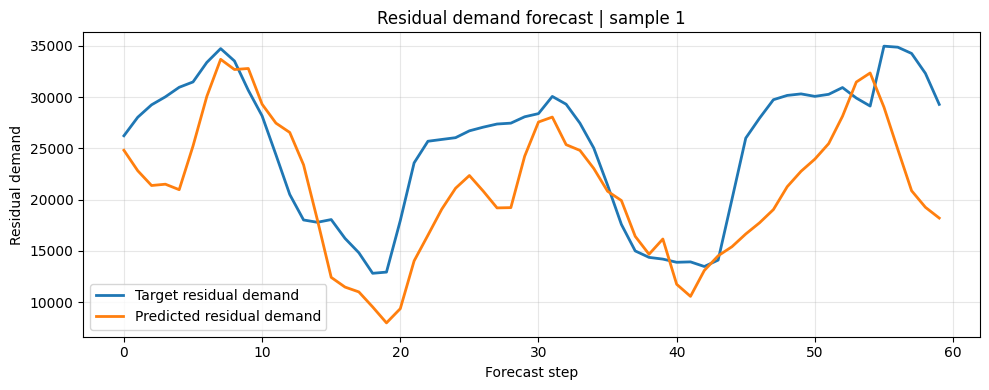

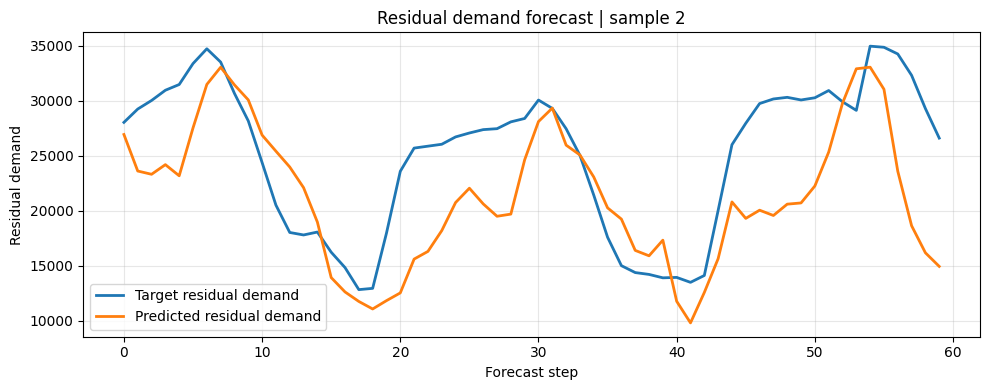

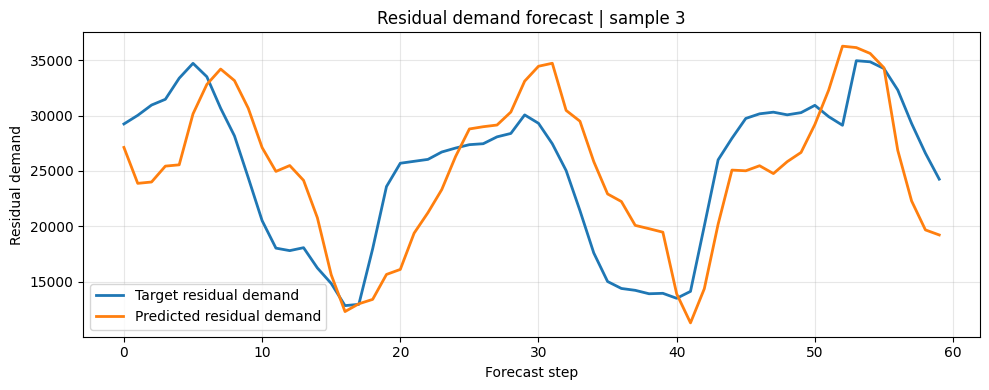

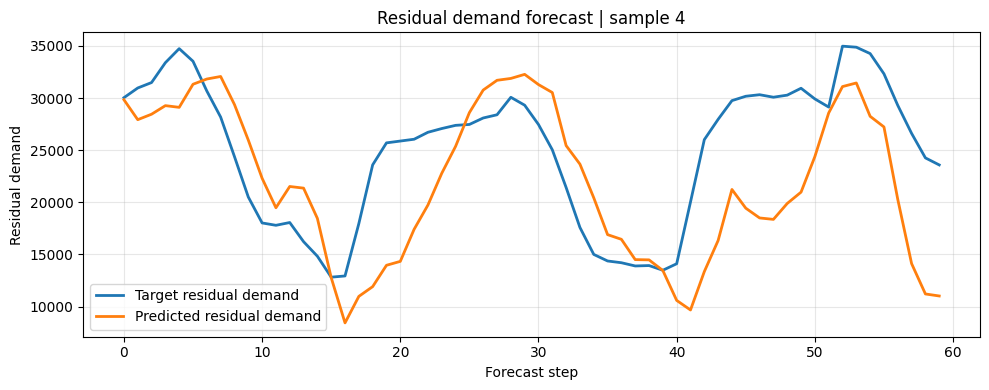

In [ ]:
plot_model = dlinear_model if "dlinear_model" in globals() else nlinear_model
plot_model.eval()

pred_level_batches = []
target_level_batches = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        pred_deltas = plot_model(batch_x)
        pred_levels, true_levels = reconstruct_levels_from_deltas(
            pred_deltas,
            batch_y,
            batch_x,
            target_index=TARGET_INDEX,
        )
        pred_level_batches.append(pred_levels.detach().cpu().numpy())
        target_level_batches.append(true_levels.detach().cpu().numpy())
        if len(pred_level_batches) >= 3:
            break

plot_predictions = np.concatenate(pred_level_batches, axis=0)
plot_targets = np.concatenate(target_level_batches, axis=0)

target_scale = scaler.scale_[TARGET_INDEX]
target_mean = scaler.mean_[TARGET_INDEX]

plot_predictions_unscaled = plot_predictions[:, :, 0] * target_scale + target_mean
plot_targets_unscaled = plot_targets[:, :, 0] * target_scale + target_mean

time_axis = np.arange(FORECAST_HORIZON)
num_samples_to_plot = min(4, plot_predictions_unscaled.shape[0])

for sample_idx in range(num_samples_to_plot):
    plt.figure(figsize=(10, 4))
    plt.plot(time_axis, plot_targets_unscaled[sample_idx], label="Target residual demand", linewidth=2)
    plt.plot(time_axis, plot_predictions_unscaled[sample_idx], label="Predicted residual demand", linewidth=2)
    plt.title(f"Residual demand forecast | sample {sample_idx + 1}")
    plt.xlabel("Forecast step")
    plt.ylabel("Residual demand")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

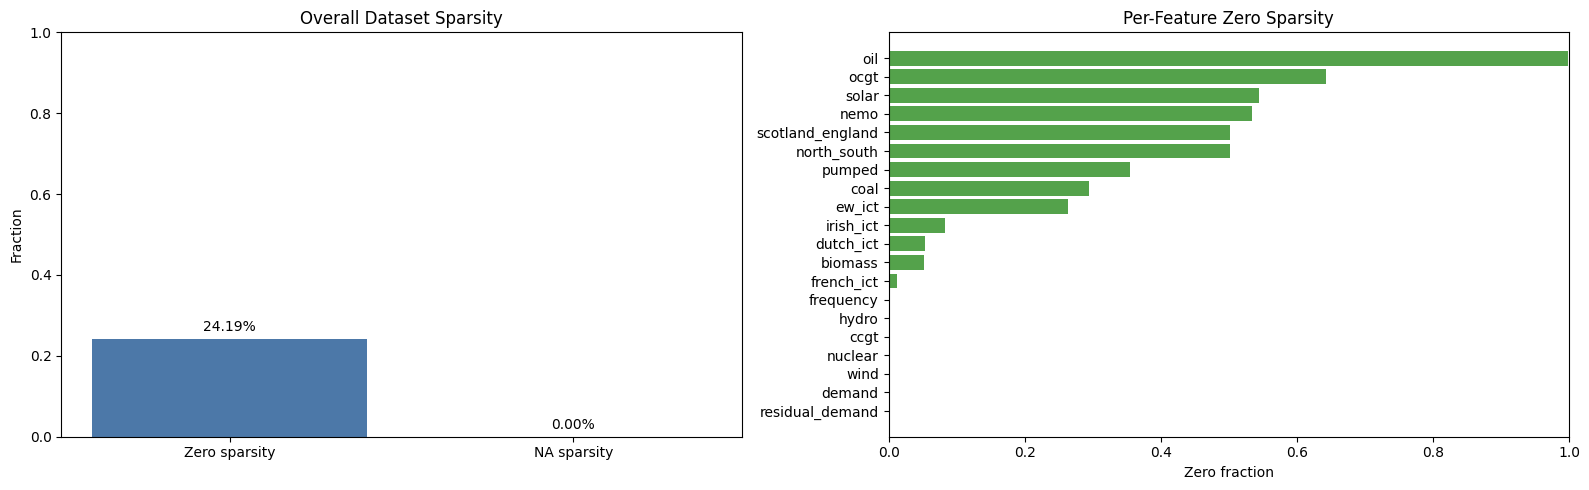

In [ ]:
zero_mask = cleangriddata.eq(0)
overall_zero_sparsity = zero_mask.to_numpy().mean()
overall_na_sparsity = cleangriddata.isna().to_numpy().mean()
per_feature_zero_sparsity = zero_mask.mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(["Zero sparsity", "NA sparsity"], [overall_zero_sparsity, overall_na_sparsity], color=["#4C78A8", "#F58518"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Fraction")
axes[0].set_title("Overall Dataset Sparsity")
for idx, value in enumerate([overall_zero_sparsity, overall_na_sparsity]):
    axes[0].text(idx, value + 0.02, f"{value:.2%}", ha="center")

axes[1].barh(per_feature_zero_sparsity.index, per_feature_zero_sparsity.values, color="#54A24B")
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Zero fraction")
axes[1].set_title("Per-Feature Zero Sparsity")

plt.tight_layout()
plt.show()

## Forecast diagnostics

In [ ]:
if "plot_model" in globals():
    diagnostic_model = plot_model
elif "dlinear_model" in globals():
    diagnostic_model = dlinear_model
elif "nlinear_model" in globals():
    diagnostic_model = nlinear_model
else:
    raise RuntimeError("No learned baseline model found for diagnostics")

diagnostic_model.eval()

diagnostic_pred_level_batches = []
diagnostic_target_level_batches = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        pred_deltas = diagnostic_model(batch_x)
        pred_levels, true_levels = reconstruct_levels_from_deltas(
            pred_deltas,
            batch_y,
            batch_x,
            target_index=TARGET_INDEX,
        )
        diagnostic_pred_level_batches.append(pred_levels.detach().cpu().numpy())
        diagnostic_target_level_batches.append(true_levels.detach().cpu().numpy())

diagnostic_predictions = np.concatenate(diagnostic_pred_level_batches, axis=0)
diagnostic_targets = np.concatenate(diagnostic_target_level_batches, axis=0)

target_scale = scaler.scale_[TARGET_INDEX]
target_mean = scaler.mean_[TARGET_INDEX]

diagnostic_predictions_unscaled = diagnostic_predictions[:, :, 0] * target_scale + target_mean
diagnostic_targets_unscaled = diagnostic_targets[:, :, 0] * target_scale + target_mean
diagnostic_residuals = diagnostic_predictions_unscaled - diagnostic_targets_unscaled
window_mae = np.mean(np.abs(diagnostic_residuals), axis=1)

print("diagnostic_predictions_unscaled shape:", diagnostic_predictions_unscaled.shape)
print("diagnostic_targets_unscaled shape:", diagnostic_targets_unscaled.shape)
print("diagnostic_residuals shape:", diagnostic_residuals.shape)
print("window_mae shape:", window_mae.shape)

diagnostic_predictions_unscaled shape: (19220, 60)
diagnostic_targets_unscaled shape: (19220, 60)
diagnostic_residuals shape: (19220, 60)
window_mae shape: (19220,)


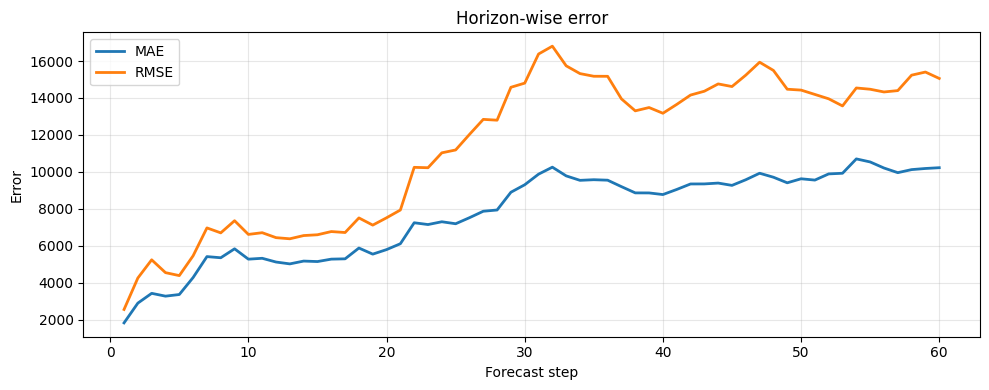

In [ ]:
horizon_steps = np.arange(1, FORECAST_HORIZON + 1)
horizon_mae = np.mean(np.abs(diagnostic_residuals), axis=0)
horizon_rmse = np.sqrt(np.mean(diagnostic_residuals ** 2, axis=0))

plt.figure(figsize=(10, 4))
plt.plot(horizon_steps, horizon_mae, label="MAE", linewidth=2)
plt.plot(horizon_steps, horizon_rmse, label="RMSE", linewidth=2)
plt.title("Horizon-wise error")
plt.xlabel("Forecast step")
plt.ylabel("Error")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

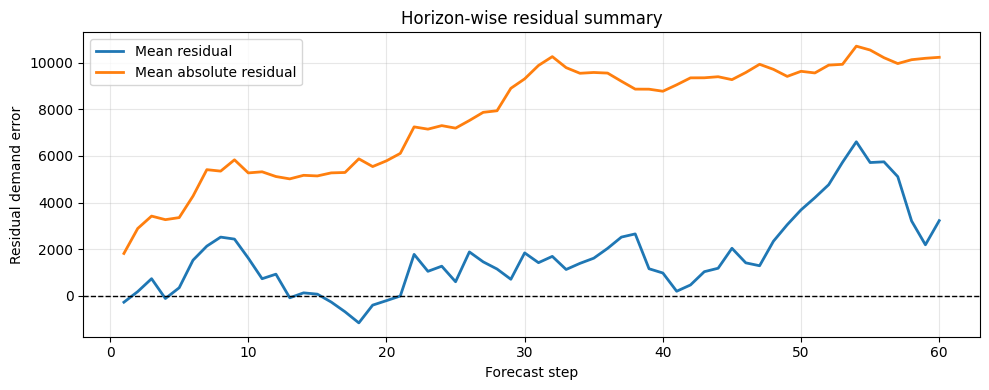

In [ ]:
horizon_steps = np.arange(1, FORECAST_HORIZON + 1)
mean_residual = np.mean(diagnostic_residuals, axis=0)
mean_abs_residual = np.mean(np.abs(diagnostic_residuals), axis=0)

plt.figure(figsize=(10, 4))
plt.plot(horizon_steps, mean_residual, label="Mean residual", linewidth=2)
plt.plot(horizon_steps, mean_abs_residual, label="Mean absolute residual", linewidth=2)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Horizon-wise residual summary")
plt.xlabel("Forecast step")
plt.ylabel("Residual demand error")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

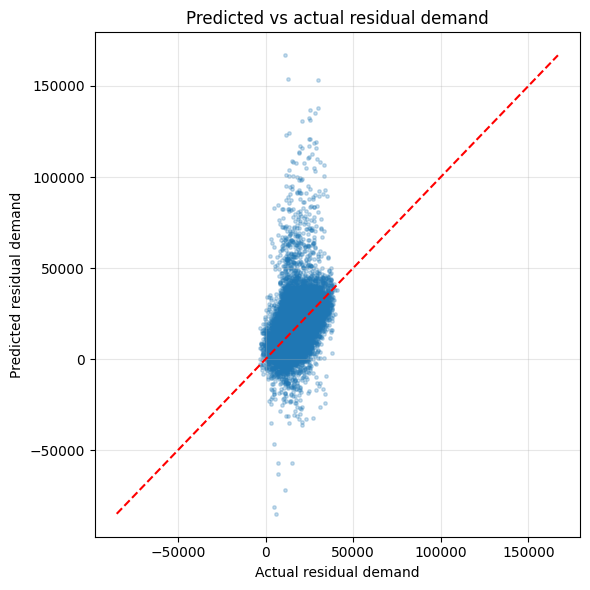

In [ ]:
flat_targets = diagnostic_targets_unscaled.reshape(-1)
flat_predictions = diagnostic_predictions_unscaled.reshape(-1)

max_points = 20000
if flat_targets.size > max_points:
    scatter_idx = np.random.default_rng(42).choice(flat_targets.size, size=max_points, replace=False)
else:
    scatter_idx = np.arange(flat_targets.size)

scatter_targets = flat_targets[scatter_idx]
scatter_predictions = flat_predictions[scatter_idx]

min_val = min(scatter_targets.min(), scatter_predictions.min())
max_val = max(scatter_targets.max(), scatter_predictions.max())

plt.figure(figsize=(6, 6))
plt.scatter(scatter_targets, scatter_predictions, s=6, alpha=0.25)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1.5)
plt.title("Predicted vs actual residual demand")
plt.xlabel("Actual residual demand")
plt.ylabel("Predicted residual demand")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

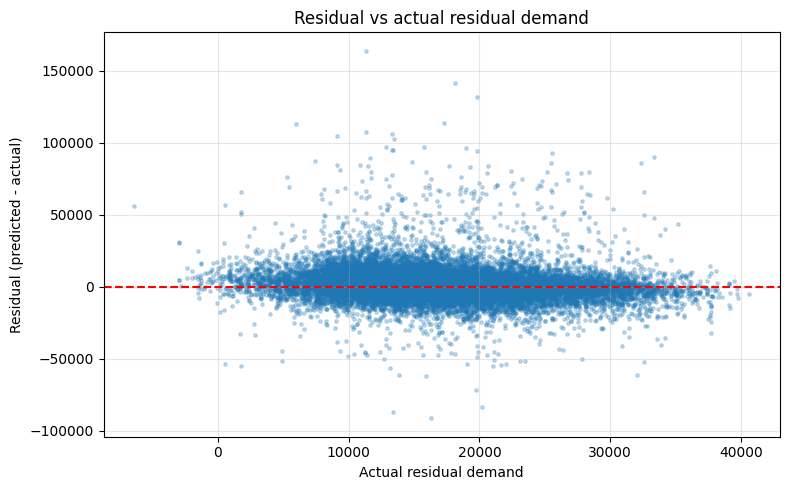

In [ ]:
flat_targets = diagnostic_targets_unscaled.reshape(-1)
flat_residuals = diagnostic_residuals.reshape(-1)

max_points = 20000
if flat_targets.size > max_points:
    scatter_idx = np.random.default_rng(43).choice(flat_targets.size, size=max_points, replace=False)
else:
    scatter_idx = np.arange(flat_targets.size)

scatter_targets = flat_targets[scatter_idx]
scatter_residuals = flat_residuals[scatter_idx]

plt.figure(figsize=(8, 5))
plt.scatter(scatter_targets, scatter_residuals, s=6, alpha=0.25)
plt.axhline(0.0, color="red", linestyle="--", linewidth=1.5)
plt.title("Residual vs actual residual demand")
plt.xlabel("Actual residual demand")
plt.ylabel("Residual (predicted - actual)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

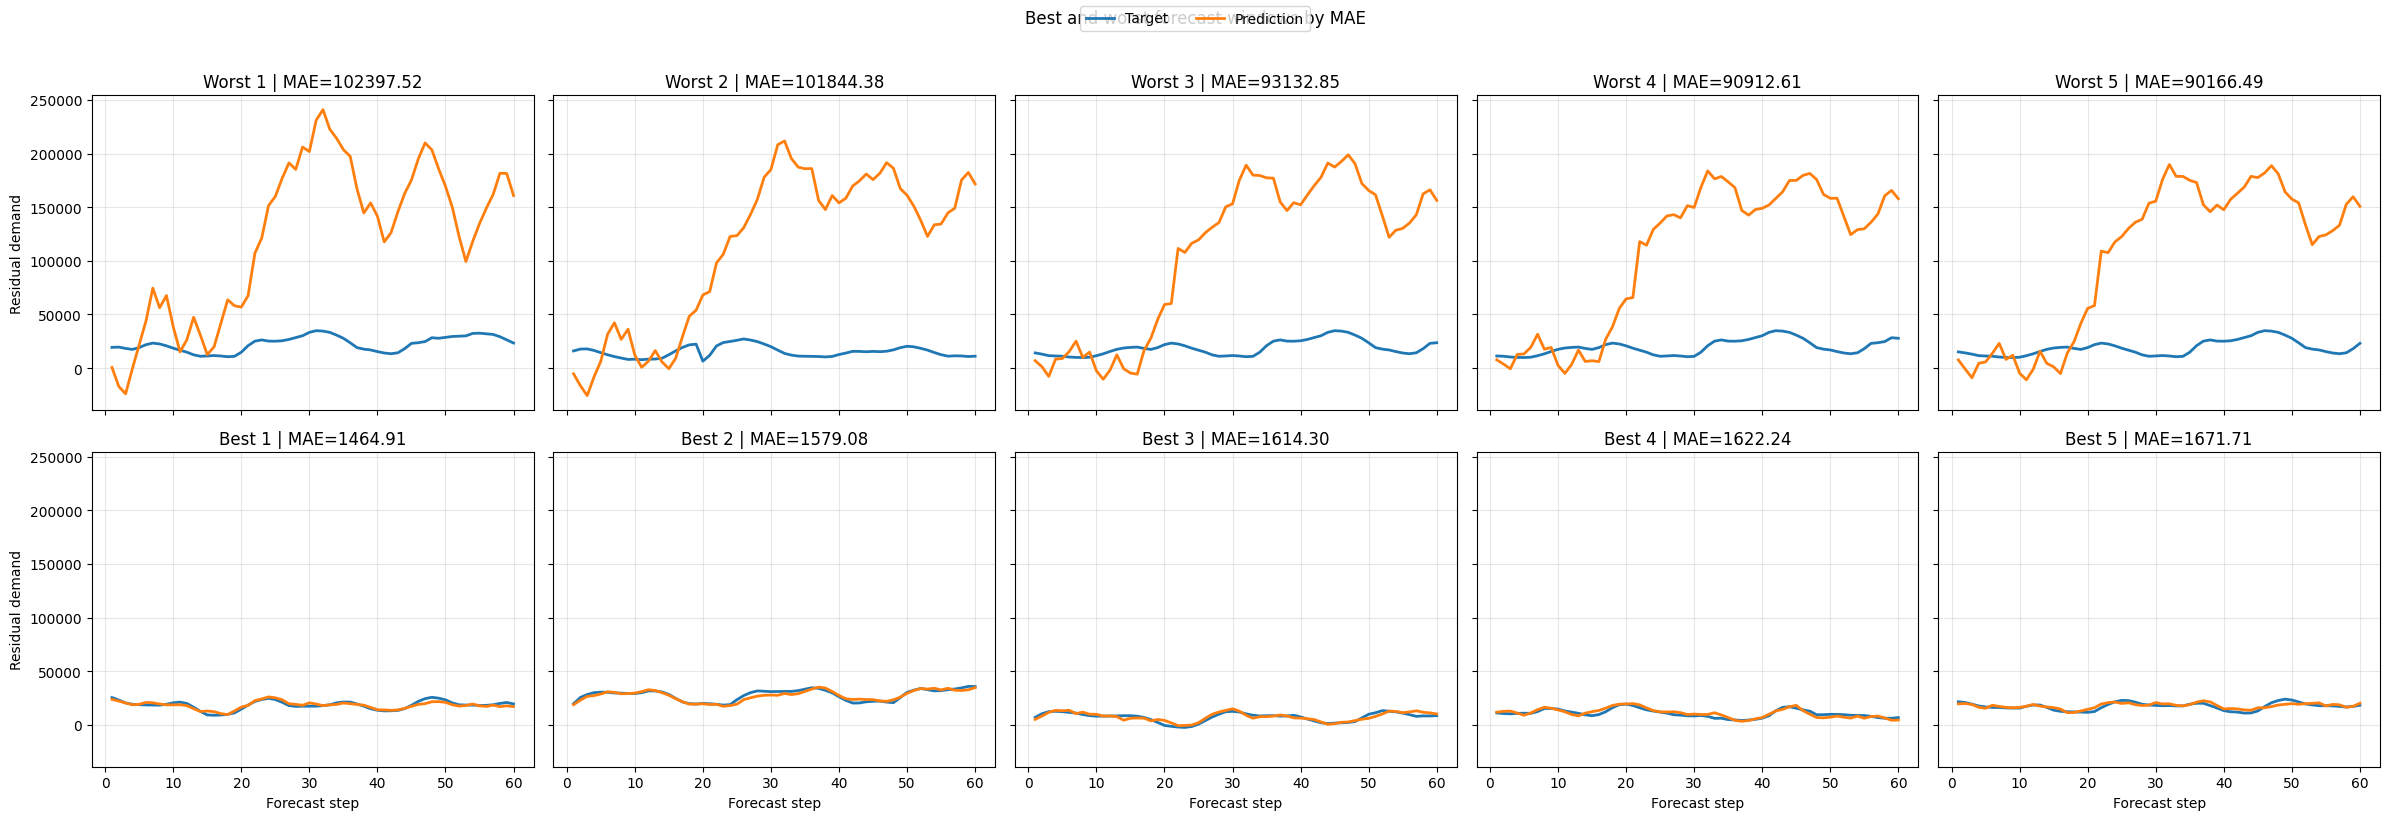

In [ ]:
num_windows = window_mae.shape[0]
worst_count = min(5, num_windows)
best_count = min(5, num_windows)

worst_indices = np.argsort(window_mae)[-worst_count:][::-1]
best_indices = np.argsort(window_mae)[:best_count]

time_axis = np.arange(1, FORECAST_HORIZON + 1)
fig, axes = plt.subplots(2, 5, figsize=(24, 8), sharex=True, sharey=True)

for col in range(5):
    ax = axes[0, col]
    if col < worst_count:
        idx = worst_indices[col]
        ax.plot(time_axis, diagnostic_targets_unscaled[idx], label="Target", linewidth=2)
        ax.plot(time_axis, diagnostic_predictions_unscaled[idx], label="Prediction", linewidth=2)
        ax.set_title(f"Worst {col + 1} | MAE={window_mae[idx]:.2f}")
    else:
        ax.axis("off")

for col in range(5):
    ax = axes[1, col]
    if col < best_count:
        idx = best_indices[col]
        ax.plot(time_axis, diagnostic_targets_unscaled[idx], label="Target", linewidth=2)
        ax.plot(time_axis, diagnostic_predictions_unscaled[idx], label="Prediction", linewidth=2)
        ax.set_title(f"Best {col + 1} | MAE={window_mae[idx]:.2f}")
    else:
        ax.axis("off")

for ax in axes.reshape(-1):
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("Residual demand")
axes[1, 0].set_ylabel("Residual demand")
for ax in axes[1, :]:
    if ax.has_data():
        ax.set_xlabel("Forecast step")

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle("Best and worst forecast windows by MAE", y=1.02)
plt.tight_layout()
plt.show()

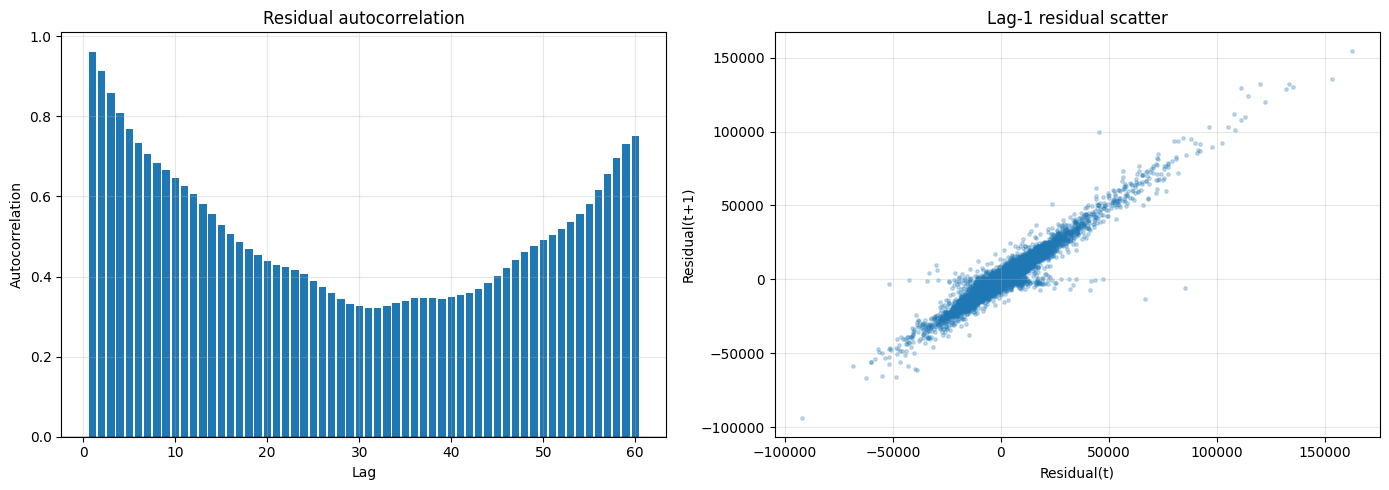

In [ ]:
flat_residuals = diagnostic_residuals.reshape(-1)
centered_residuals = flat_residuals - flat_residuals.mean()

denominator = np.dot(centered_residuals, centered_residuals)
max_lag = min(60, centered_residuals.size - 1)
lags = np.arange(1, max_lag + 1)

acf_values = np.zeros(max_lag)
if denominator > 0 and max_lag > 0:
    for lag in lags:
        acf_values[lag - 1] = np.dot(centered_residuals[:-lag], centered_residuals[lag:]) / denominator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lags, acf_values, width=0.8)
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title("Residual autocorrelation")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")
axes[0].grid(alpha=0.3)

if centered_residuals.size > 1:
    lag0 = centered_residuals[:-1]
    lag1 = centered_residuals[1:]
    max_points = 20000
    if lag0.size > max_points:
        scatter_idx = np.random.default_rng(44).choice(lag0.size, size=max_points, replace=False)
    else:
        scatter_idx = np.arange(lag0.size)

    axes[1].scatter(lag0[scatter_idx], lag1[scatter_idx], s=6, alpha=0.25)
    axes[1].set_title("Lag-1 residual scatter")
    axes[1].set_xlabel("Residual(t)")
    axes[1].set_ylabel("Residual(t+1)")
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "Not enough residuals", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Next steps
Use the best deterministic baseline from the table as the immediate starting point for a scenario generator extension.